In [1]:
#Q1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


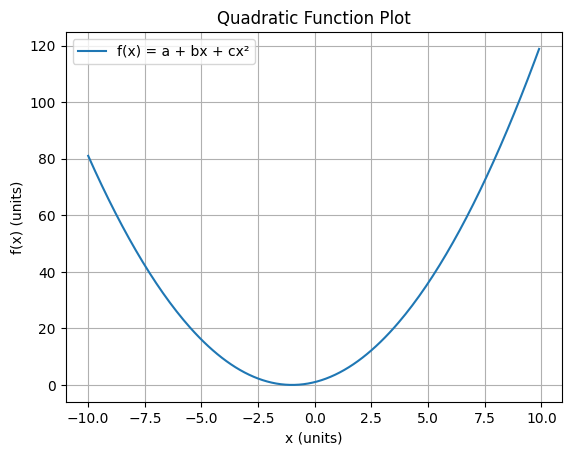

In [3]:
#Q1.1
a = 1
b = 2
c = 1
def f(x):
    return a + b*x + c*(x**2)

x = np.arange(-10, 10, 0.1)
y = np.vectorize(f)(x)

plt.plot(x, y, label="f(x) = a + bx + cx^2")`nplt.title("Quadratic Function Plot")
plt.xlabel("x (units)")
plt.ylabel("f(x) (units)")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
#Q1.2
def grad_f(x):
    return 2*c*(x)+b

#Q1.3
The critical point is (-1,0)

In [5]:
#Q1.4
def grad_update(grad_func, x, eta):
    return x - eta * grad_func(x)


In [6]:
# Q1.5

def min_find(x_init, epsilon, eta):
    x_i = x_init
    x_values = [x_i]  # list to store the path of x values
    x_i1 = grad_update(grad_f, x_i, eta)

    # continue updating while the change is larger than epsilon
    while abs(x_i1 - x_i) > epsilon:
        x_i = x_i1
        x_values.append(x_i)          # store the new value
        x_i1 = grad_update(grad_f, x_i, eta)

    return x_values
# Runing Gradient Descent
# We chose the parameters as below:
x_path = min_find(100, 0.001, 0.01)
x_final = x_path[-1]   # last x in the path
print("Minimum point found by Gradient Descent:", x_final)
print("Function value at minimum:", f(x_final))
# Analytical solution (from section 3)
x_min = -b / (2*c)
print("Analytical minimum point:", x_min)


Minimum point found by Gradient Descent: -0.9502776198229612
Function value at minimum: 0.0024723150904699676
Analytical minimum point: -1.0


The x value we obtained is close to, but not identical with, the result from section 1.3 because the epsilon parameter we selected is not zero, so the result is only approximately the same.

In [7]:
#Q1.6
T_min = np.inf
T_min_x = None
T_min_parameters = None
# Loop over the range of epsilon, eta, and x_0
for epsilon in np.arange(0.1, 0.0, -0.01):
    for eta in np.arange(0.2, 0.0, -0.01):
        for x_0 in np.arange(50, 5, -1):
            ret = min_find(x_0, epsilon, eta)
            if len(ret) < T_min:
                T_min = len(ret)
                T_min_x = ret
                T_min_parameters = (x_0, epsilon, eta)
# Print the results
print(f'The algorithm is fastest with:\n'
f'x_0 = {T_min_parameters[0]}\n'
f'epsilon = {T_min_parameters[1]}\n'
f'eta = {T_min_parameters [2]:.2f}\n'
f'T = {T_min}')


The algorithm is fastest with:
x_0 = 7
epsilon = 0.1
eta = 0.20
T = 8


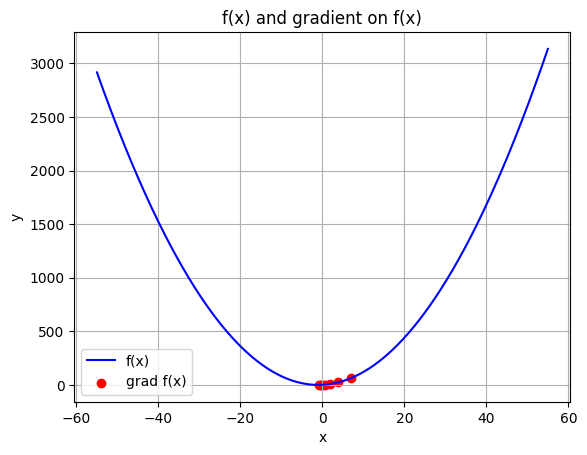

In [8]:
#Q1.7
x = np.arange(-55,55,0.01)
y = np.vectorize(f)(x)
plt.plot(x,y,color='blue', label='f(x)')
y_min = np.vectorize(f)(T_min_x)
plt.scatter(T_min_x, y_min,color='red',
label='grad f(x)')
plt.title('f(x) and gradient on f(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

#Q2

In [9]:
#Q2.4
def sub_gradient(w, b, X, y, lam, i):
    """
    Calculates the subgradient of the SVM objective function
    for a single training sample.
    Returns the gradient with respect to w and b.
    """

    # Regularization part
    grad_w = 2 * lam * w
    grad_b = 0

    # Check if the sample violates the margin
    if y[i] * (np.dot(w, X[i]) + b) <= 1:
        grad_w = grad_w - y[i] * X[i]
        grad_b = grad_b - y[i]

    return grad_w, grad_b


In [10]:
def svm_with_sgd(X, y, lam=0, epochs=1000, l_rate=0.01, sgd_type='practical'):
    """
    Parameters:
    X (ndarray): Training data, shape (m, d).
    y (ndarray): Labels vector, shape (m,).
    lam (float): Regularization coefficient.
    epochs (int): Number of training passes.
    l_rate (float): Step size for updates.
    sgd_type (str): 'practical' for shuffled SGD or 'theory' for averaged SGD.
    Returns:
    (w, b) for practical SGD, or (w_avg, b_avg) for theoretical SGD.
    """
    np.random.seed(2)  # for reproducibility
    # Get dataset size
    m, d = X.shape
    w = np.random.uniform(0, 1, d)
    b = np.random.uniform(0, 1)
    if sgd_type == 'practical':
        for _ in range(epochs):
            # Shuffle data each epoch
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(m):
                grad_w, grad_b = sub_gradient(w, b, X_shuffled, y_shuffled, lam, i)

                # Update rule
                w = w - l_rate * grad_w
                b = b - l_rate * grad_b

        return w, b

    #  THEORETICAL SGD
    else:
        w_sum = np.zeros(d)
        b_sum = 0
        T = epochs * m

        for _ in range(T):

            # Sample one index randomly
            i = np.random.randint(m)

            grad_w, grad_b = sub_gradient(w, b, X, y, lam, i)

            # Update rule
            w = w - l_rate * grad_w
            b = b - l_rate * grad_b

            # Accumulate weights
            w_sum += w
            b_sum += b

        # Compute averages
        w_avg = w_sum / T
        b_avg = b_sum / T

        return w_avg, b_avg


In [11]:
#Q2.5
def calculate_error(w, bias, X, y):
    """
    Computes the fraction of incorrect predictions made by the classifier.
    """
    m = X.shape[0]   # number of samples
    errors = 0

    for i in range(m):
        prediction = np.dot(w, X[i]) + bias

        if y[i] * prediction < 0:
            errors += 1

    return errors / m


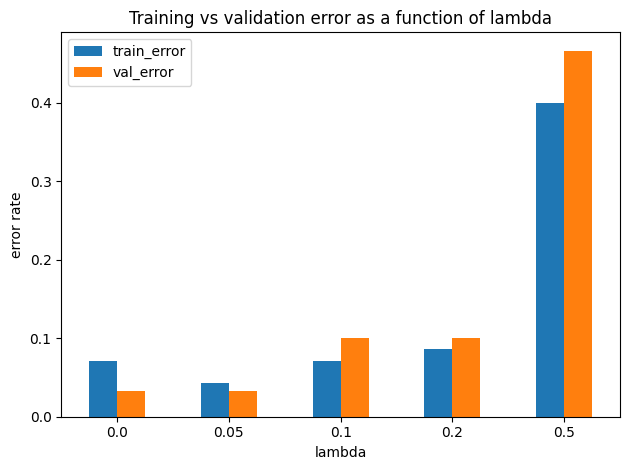

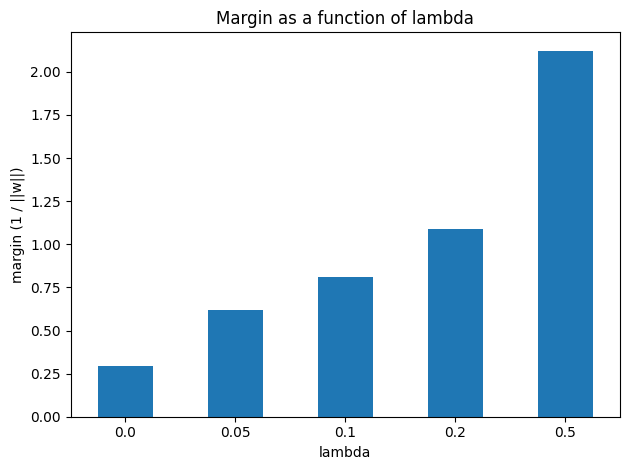

In [12]:
#Q2.6
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
X = X[y != 0]
y = y[y != 0]
y[y==2] = -1
X = X[:, 2:4]

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=0)
lamda = [0, 0.05, 0.1, 0.2, 0.5]

# Lists to store results
train_errors = []      # training set error
val_errors = []        # validation set error
margins = []           # geometric margin

for lam in lamda:
    # fit SVM with current regularization
    w, b = svm_with_sgd(X_train, y_train, lam=lam)

    # compute errors on train and validation sets
    train_errors.append(calculate_error(w, b, X_train, y_train))
    val_errors.append(calculate_error(w, b, X_val, y_val))

    # margin for linear SVM is 1 / ||w||
    margins.append(1 / np.linalg.norm(w))

df = pd.DataFrame({
    'lambda': lamda,
    'train_error': train_errors,
    'val_error': val_errors,
    'margin': margins
})

fig, ax = plt.subplots()
df.plot(kind='bar', x='lambda', y=['train_error', 'val_error'], ax=ax)
ax.set_xlabel('lambda')
ax.set_ylabel('error rate')
ax.set_title('Training vs validation error as a function of lambda')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
fig, ax = plt.subplots()
df.plot(kind='bar', x='lambda', y='margin', ax=ax, legend=False)
ax.set_xlabel('lambda')
ax.set_ylabel('margin (1 / ||w||)')
ax.set_title('Margin as a function of lambda')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()


The model that appears best is the one with lambda = 0.05 because it has the lowest average training and validation errors, while its margin is not the smallest. This suggests it generalizes well and does not show substantial overfitting on the training set. In contrast, the models with lambda values of 0.1, 0.2, and 0.5 appear to overfit, since their training error is lower than their validation error. As lambda increases, the margin also increases, which matches the expectation that stronger regularization penalizes large weights and widens the margin. The widest margin does not produce the lowest error, so the relationship between margin size and accuracy is not monotonic.

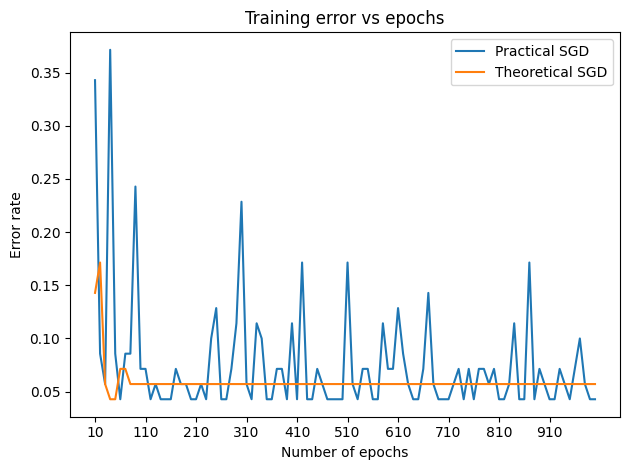

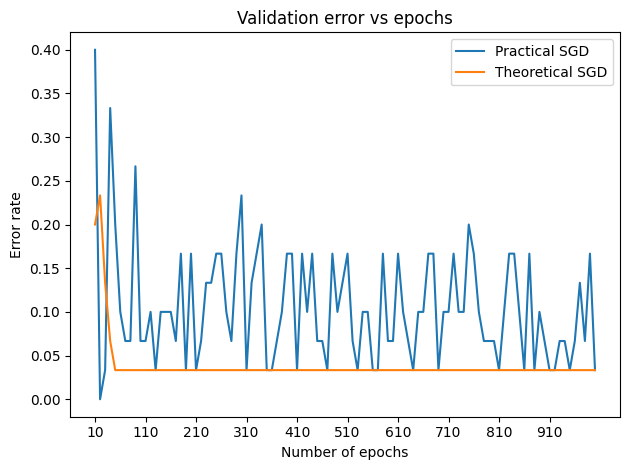

In [13]:
#Q2.7
# Parameters
lambda_val = 0.05
epoch_range = np.arange(10, 1001, 10)

# Lists for storing results
train_err_prac = []
train_err_theo = []
val_err_prac = []
val_err_theo = []

# Loop over different epoch values
for ep in epoch_range:

    # Train using practical SGD
    w_prac, b_prac = svm_with_sgd(X_train, y_train, lam=lambda_val,
                                  epochs=ep, l_rate=0.01, sgd_type='practical')

    train_err_prac.append(calculate_error(w_prac, b_prac, X_train, y_train))
    val_err_prac.append(calculate_error(w_prac, b_prac, X_val, y_val))

    # Train using theoretical SGD
    w_theo, b_theo = svm_with_sgd(X_train, y_train, lam=lambda_val,
                                  epochs=ep, l_rate=0.01, sgd_type='theory')

    train_err_theo.append(calculate_error(w_theo, b_theo, X_train, y_train))
    val_err_theo.append(calculate_error(w_theo, b_theo, X_val, y_val))


# Build DataFrame
results_df = pd.DataFrame({
    'epochs': epoch_range,
    'train_practical': train_err_prac,
    'val_practical': val_err_prac,
    'train_theory': train_err_theo,
    'val_theory': val_err_theo
})


# --- Plot training errors ---
fig, ax = plt.subplots()
results_df.plot(x='epochs', y=['train_practical', 'train_theory'], ax=ax)

ax.set_xlabel('Number of epochs')
ax.set_ylabel('Error rate')
ax.set_title('Training error vs epochs')
ax.set_xticks(np.arange(10, 1010, 100))
ax.legend(['Practical SGD', 'Theoretical SGD'])
plt.tight_layout()


# --- Plot validation errors ---
fig, ax = plt.subplots()
results_df.plot(x='epochs', y=['val_practical', 'val_theory'], ax=ax)

ax.set_xlabel('Number of epochs')
ax.set_ylabel('Error rate')
ax.set_title('Validation error vs epochs')
ax.set_xticks(np.arange(10, 1010, 100))
ax.legend(['Practical SGD', 'Theoretical SGD'])
plt.tight_layout()


The gap between training and validation errors shows that the practical and theoretical SGD methods behave differently. On the training set, the practical method has higher variance because the weights are updated after each sample and the sample order is randomized, which causes visible oscillations. On the validation set, the same method often has even higher variance and sometimes higher error, which indicates overfitting in some iterations. The theoretical method produces more stable errors on both the training and validation sets and therefore appears to generalize better.

#Q3

In [14]:
#Q3.1
def cross_validation_error(X, y, model, k_folds):
    """
    Performs k-fold cross validation and returns the average
    training and validation error.
    """
    train_err_list = []
    val_err_list = []
    # Shuffle data indices and split into folds
    indices = np.random.permutation(X.shape[0])
    split_folds = np.array_split(indices, k_folds)
    for k in range(k_folds):
        val_idx = split_folds[k]
        train_idx = np.setdiff1d(indices, val_idx)
        # Build train and validation sets
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_va, y_va = X[val_idx], y[val_idx]
        # Train model
        model.fit(X_tr, y_tr)
        # Predictions
        y_tr_pred = model.predict(X_tr)
        y_va_pred = model.predict(X_va)
        # Compute error rates (1 - accuracy)
        train_error = 1 - np.mean(y_tr_pred == y_tr)
        val_error = 1 - np.mean(y_va_pred == y_va)
        # Save results
        train_err_list.append(train_error)
        val_err_list.append(val_error)

    # Average results
    avg_train_error = np.mean(train_err_list)
    avg_val_error = np.mean(val_err_list)

    return avg_train_error, avg_val_error


In [15]:
#Q3.2
from sklearn.svm import SVC
def svm_results(X_train, y_train, X_test, y_test):
    """
    Trains linear SVM models with different regularization values,
    performs cross-validation, and evaluates on a test set.
    Returns a dictionary with the results.
    """

    lambda_values = [10**(-4), 10**(-2), 1, 10**2, 10**4]
    k = 5
    output = {}

    for lam in lambda_values:
        C_value = 1 / lam  # Convert lambda to C
        clf = SVC(kernel='linear', C=C_value)

        # Cross-validation on training data
        avg_tr_err, avg_val_err = cross_validation_error(X_train, y_train, clf, k)

        # Train on entire training set
        clf.fit(X_train, y_train)
        test_pred = clf.predict(X_test)
        test_err = np.mean(test_pred != y_test)

        # Save results
        key = f"SVM_lambda_{lam}"
        output[key] = (avg_tr_err, avg_val_err, test_err)

    return output


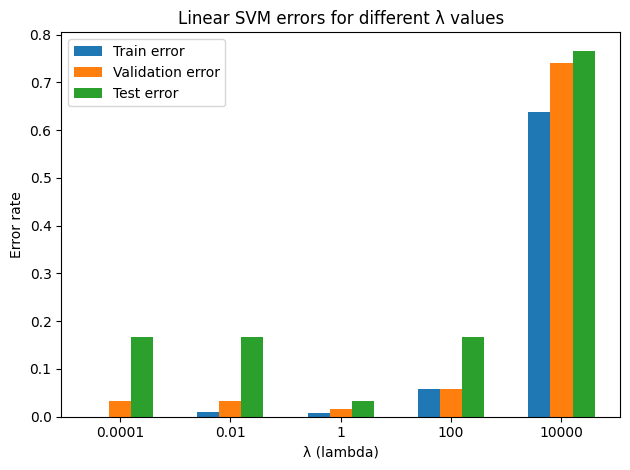

In [16]:
#Q3.3
iris = load_iris()
X, y = iris.data, iris.target

lambda_vals = [10**(-4), 10**(-2), 1, 10**2, 10**4]

# Split into train / test
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=7
)

# Run SVM experiments for different lambdas
results = svm_results(X_tr, y_tr, X_te, y_te)

train_errs = [results[f"SVM_lambda_{lam}"][0] for lam in lambda_vals]
val_errs   = [results[f"SVM_lambda_{lam}"][1] for lam in lambda_vals]
test_errs  = [results[f"SVM_lambda_{lam}"][2] for lam in lambda_vals]

positions = np.arange(len(lambda_vals))
width = 0.2
plt.bar(positions, train_errs, width=width, label="Train error")
plt.bar(positions + width, val_errs, width=width, label="Validation error")
plt.bar(positions + 2*width, test_errs,  width=width, label="Test error")

plt.xlabel("lambda")
plt.ylabel("Error rate")
plt.title("Linear SVM errors for different lambda values")
plt.xticks(positions + width, lambda_vals)
plt.legend()
plt.tight_layout()
plt.show()


According to cross-validation, the best model is the one with lambda = 0.01 because it achieves the lowest validation error. According to the external test set, however, the best model is the one with lambda = 1 because it yields the lowest classification error there. These are therefore not the same model. The difference is expected because cross-validation estimates generalization by repeatedly splitting the training data, so the estimate can still depend on the exact partition and on sampling noise. The independent test set was not used during training or model selection, so it can identify a different model as best. In practice, this means cross-validation is useful but not guaranteed to pick the model that performs best on every unseen sample.